In [1]:
from io import StringIO

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from pint.models import get_model
from pint.simulation import make_fake_toas_uniform
from pint import dmu
from pint.residuals import WidebandTOAResiduals

from enterprise_wideband.pulsar import WidebandPulsar
from enterprise_wideband.signals import WidebandMeasurementNoise, WidebandTimingModel
from enterprise_wideband.blocks import solar_wind_noise_powerlaw_block
from enterprise.signals.signal_base import PTA

from PTMCMCSampler.PTMCMCSampler import PTSampler
import corner

/home/abhimanyu/miniconda3/envs/enterprise/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


In [2]:
par = """
    PSR         SWTEST
    RAJ         05:00:00    1
    DECJ        15:00:00    1
    PMRA        1e-6        0
    PMDEC       1e-6        0
    POSEPOCH    55000
    F0          100         1
    F1          1e-15       1
    PEPOCH      55000
    DM          18          1
    DM1         -1e-4       1
    DM2         1e-6        1
    DMEPOCH     55000
    NE_SW       4           1
    NE_SW1      1e-3        1
    SWEPOCH     55000
    TNSWAMP     -7
    TNSWGAM     3
    TNSWC       30
    UNITS       TDB
    EPHEM       DE440
    CLOCK       TT(BIPM2021)
    PLANET_SHAPIRO Y
"""
m = get_model(StringIO(par))

In [3]:
tsim = make_fake_toas_uniform(
    model=m,
    startMJD=53000,
    endMJD=57000,
    ntoas=1000,
    freq=1000*u.MHz,
    obs="gbt",
    wideband=True,
    error=0.5*u.us,
    wideband_dm_error=1e-5*dmu,
    add_noise=True,
    add_correlated_noise=True,
    include_bipm=True,
)

2026-03-07 12:17:26.304 | INFO     | pint.simulation:get_fake_toa_clock_versions:106 - Using CLOCK = BIPM2021 from the given model
2026-03-07 12:17:26.350 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-03-07 12:17:26.352 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-03-07 12:17:26.389 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-03-07 12:17:26.389 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2026-03-07 12:17:26.393 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2026-03-07 12:17:26.395 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file gps2utc.clk (/home/abhimanyu/.astropy/cache/download/url/d3c81b5766f4

Text(0, 0.5, 'DM (dmu)')

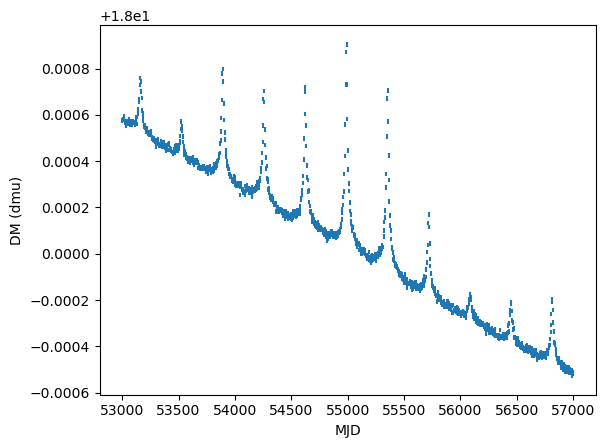

In [4]:
plt.errorbar(tsim.get_mjds(), tsim.get_dms(), tsim.get_dm_errors(), ls="")
plt.xlabel("MJD")
plt.ylabel("DM (dmu)")

2026-03-07 12:17:28.880 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
2026-03-07 12:17:28.940 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
2026-03-07 12:17:28.953 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
2026-03-07 12:17:28.967 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
2026-03-07 12:17:28.979 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because

Text(0, 0.5, 'DM wres')

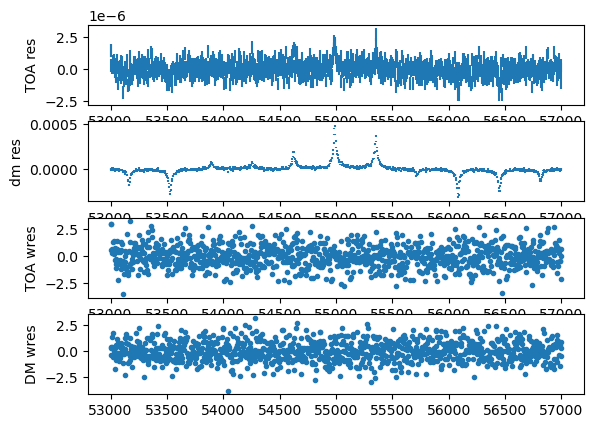

In [5]:
res = WidebandTOAResiduals(tsim, m)

plt.subplot(411)
plt.errorbar(tsim.get_mjds(), res.toa.calc_time_resids(), res.toa.get_data_error(), ls="")
plt.ylabel("TOA res")

plt.subplot(412)
plt.errorbar(tsim.get_mjds(), res.dm.calc_resids(), res.dm.get_data_error(), ls="")
plt.ylabel("dm res")

plt.subplot(413)
plt.scatter(tsim.get_mjds(), res.calc_whitened_resids(), marker=".")
plt.ylabel("TOA wres")

plt.subplot(414)
plt.scatter(tsim.get_mjds(), res.calc_whitened_dm_resids(), marker=".")
plt.ylabel("DM wres")

In [6]:
psr = WidebandPulsar(tsim, m)

2026-03-07 12:17:29.305 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
2026-03-07 12:17:29.394 | WARNING  | pint.models.noise_model:get_rednoise_freqs:1319 - Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.


In [7]:
tm = WidebandTimingModel()
wn = WidebandMeasurementNoise(efac=1, dmefac=1)
swn = solar_wind_noise_powerlaw_block(name="swgp")

model = tm + wn + swn

In [8]:
pta = PTA([model(psr)])

In [9]:
print(pta.param_names)

['SWTEST_swgp_gamma', 'SWTEST_swgp_log10_A']


In [10]:
x0 = np.array([p.sample() for p in pta.params])

In [11]:
psr.planetssb[:, 2, :3].shape, psr.sunssb[:, :3].shape

((2000, 3), (2000, 3))

In [12]:
pta.get_lnlikelihood(x0)

KernelMatrix(23166.62804089)

In [13]:
# dimension of parameter space
ndim = len(x0)

# initial jump covariance matrix
cov = np.diag(np.ones(ndim) * 0.01**2)

# intialize sampler
sampler = PTSampler(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir="swgp_chains/")

In [14]:
N = 100000
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Finished 1.00 percent in 0.299572 s Acceptance rate = 0.812

/home/abhimanyu/miniconda3/envs/enterprise/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 10.00 percent in 2.663538 s Acceptance rate = 0.26793Adding DE jump with weight 50
Finished 100.00 percent in 23.035781 s Acceptance rate = 0.42578
Run Complete


In [15]:
chain = np.loadtxt("swgp_chains/chain_1.txt")
burn = int(0.25 * chain.shape[0])

In [16]:
labels = ["gamma_sw", "log10_A_sw"]
true_values = [m["TNSWGAM"].value, m["TNSWAMP"].value]

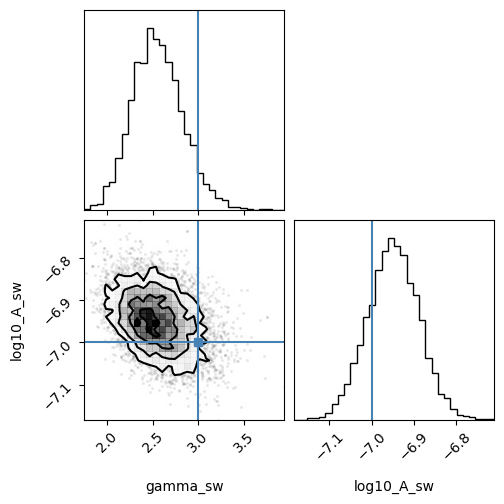

In [17]:
corner.corner(
    chain[burn:, :-4],
    bins=32,
    truths=true_values,
    labels=labels,
);